In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch

In [2]:
import sys
from pathlib import Path

# добавление директории проекта в путь, чтоб подрубить модули
sys.path.insert(0, str(Path.cwd().parent))

In [3]:
from src.diffusion_model.training import train_somvae_diffusion_refiner
from src.diffusion_model.inference import *
from src.datasets.dataset import *
from src.som_vae.model import *
from src.som_vae.training import *

# Подгрузка датасета

In [4]:
# Download latest version
path = kagglehub.dataset_download("apollo2506/eurosat-dataset")

print("Path to dataset files:", path)
img_path = os.path.join(path, "EuroSAT")

Path to dataset files: /home/mihalko711/.cache/kagglehub/datasets/apollo2506/eurosat-dataset/versions/6


In [5]:
train_dataset = EuroSATDataset(Path(img_path) / "train.csv", image_root=img_path, return_label=True, transform=get_train_transform())
val_dataset = EuroSATDataset(Path(img_path) / "validation.csv", image_root=img_path, return_label=True, transform=get_val_transform())

Text(0.5, 1.0, 'Class: Forest')

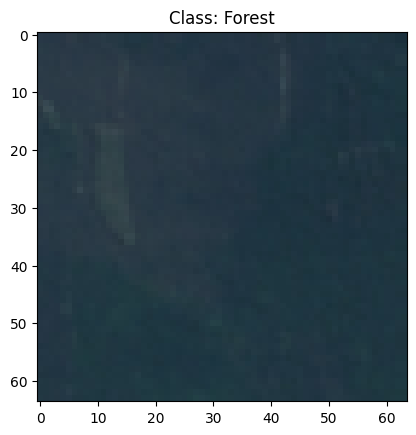

In [6]:
example = train_dataset[np.random.randint(len(train_dataset))]
plt.imshow((example[0].transpose(2, 0) + 1) / 2)
plt.title(f"Class: {example[-1]}")

# Подгрузка модели сома

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [42]:
path_to_model = "../checkpoints/som_vae_16x16_base_dotren_1.pth"
params = {"grid_size" : (16, 16), "latent_dim" : (32, 4, 4)}

In [43]:
som_model, metadata = load_model(path_to_model, device, params)

/home/mihalko711/some_code/topogen-earth/src/som_vae/training.py:315: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


tensor(0.0199)

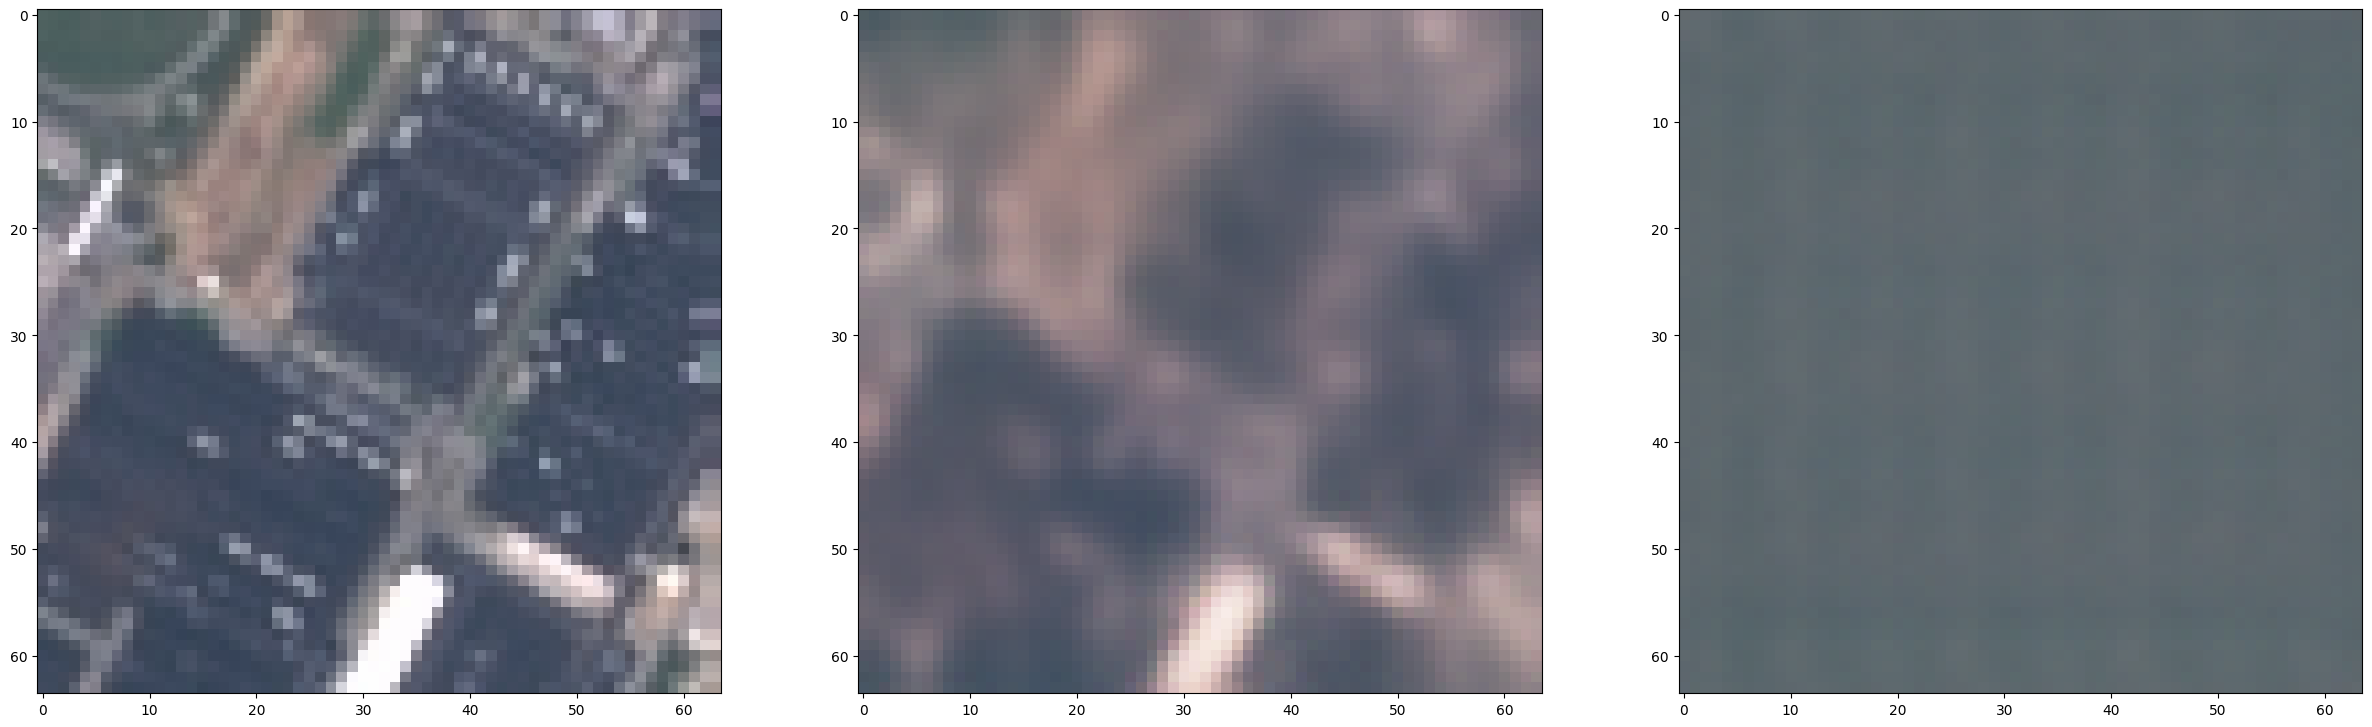

In [82]:
example_imag = train_dataset[np.random.randint(len(train_dataset))][0].unsqueeze(0).to(device)
x_hat_e, x_hat_q, z_e, z_q, indices, logits = som_model(example_imag)

orig_img = (example_imag.squeeze(0).permute(1, 2, 0).detach().cpu() + 1) / 2
rec_img = (x_hat_e.squeeze(0).permute(1, 2, 0).detach().cpu() + 1) / 2
rec_lat_img = (x_hat_q.squeeze(0).permute(1, 2, 0).detach().cpu() + 1) / 2

fig, ax = plt.subplots(1, 3, figsize = (30, 10))

ax[0].imshow(orig_img)
ax[1].imshow(rec_img)
ax[2].imshow(rec_lat_img)

((orig_img - rec_lat_img)**2).mean()

# Попитка тренировки

In [10]:
epochs = 5
lr = 5e-4
batch_size = 32

In [11]:
refiner = train_somvae_diffusion_refiner(som_model, 
                                         train_dataset, val_dataset,
                                        epochs, batch_size,
                                        lr, device,
                                        timesteps=100, num_inference_steps=50)

Training Epoch 1/5:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 1/5: Train Loss = 0.0575, Val Loss = 0.0331


Training Epoch 2/5:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 2/5: Train Loss = 0.0309, Val Loss = 0.0301


Training Epoch 3/5:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 3/5: Train Loss = 0.0290, Val Loss = 0.0283


Training Epoch 4/5:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 4/5: Train Loss = 0.0272, Val Loss = 0.0265


Training Epoch 5/5:   0%|          | 0/591 [00:00<?, ?it/s]

Epoch 5/5: Train Loss = 0.0265, Val Loss = 0.0265


torch.Size([1, 3, 64, 64])


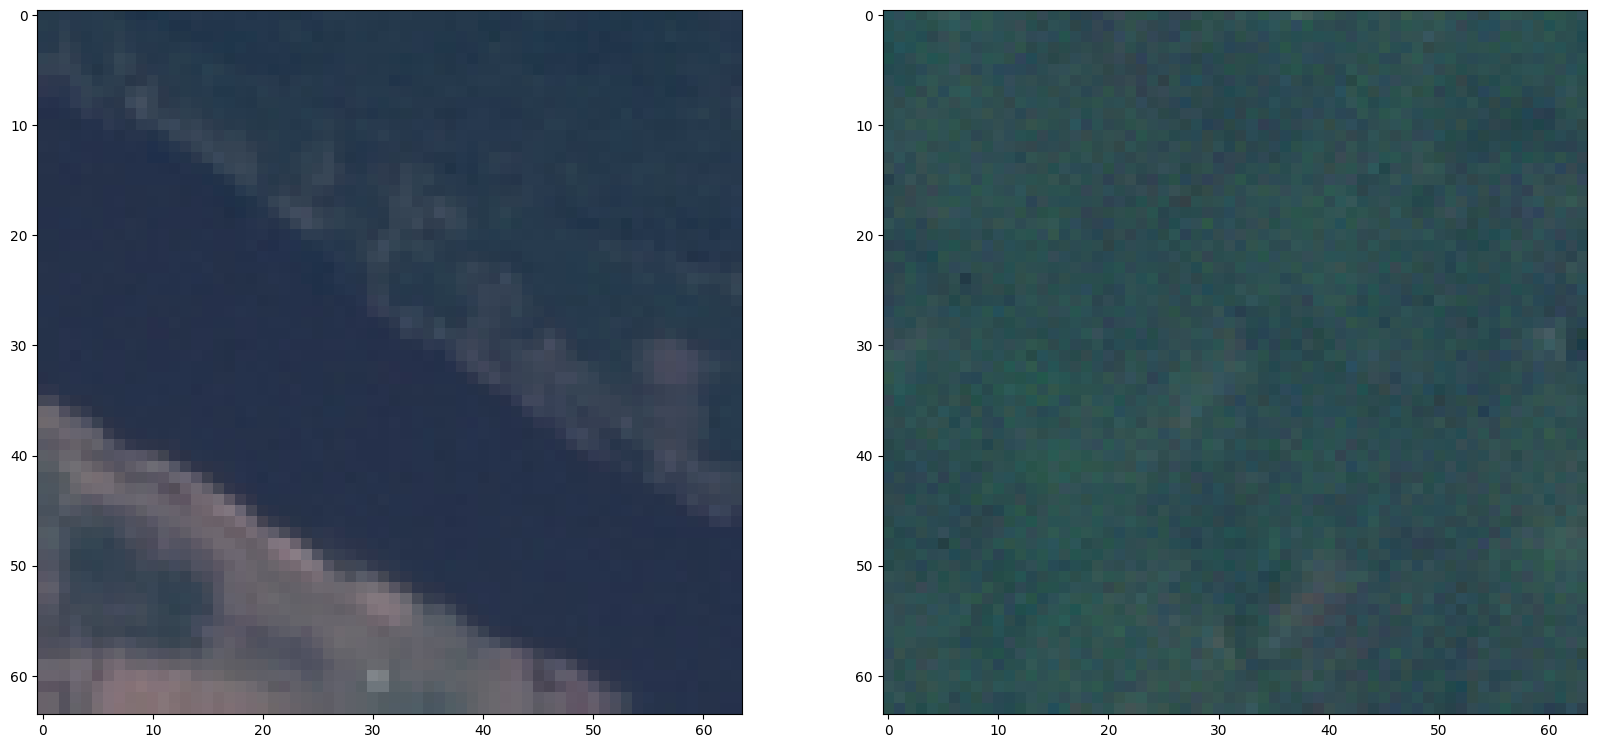

In [65]:
imag = train_dataset[np.random.randint(len(train_dataset))][0].unsqueeze(0).to(device)
refined_recon = refiner.sample_ddim(som_model, imag, start_from_t=50, num_inference_steps=70)
print(refined_recon.shape)

refined_img = (refined_recon.squeeze(0).permute(1, 2, 0) + 1) / 2

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow((imag.squeeze(0).cpu().permute(1, 2, 0) + 1) / 2)
ax[1].imshow(refined_img.cpu())